### Import

In [1]:
import sys
import os

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
print(module_path)

/Users/robertocarlos/projects


In [3]:
from src.features import preprocess_trip_data

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import root_mean_squared_log_error

### Load data

In [5]:
# Load data
train_data = pd.read_csv('/Users/robertocarlos/Documents/datasets/nyc-taxi-trip-duration/train.csv')
test_data = pd.read_csv('/Users/robertocarlos/Documents/datasets/nyc-taxi-trip-duration/test.csv')

### EDA

In [6]:
# Train data information
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [7]:
# Train data exploration
print("Train data shape:", train_data.shape)
train_data.head()

Train data shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [8]:
print("Missing values in train data: {}".format(train_data.isnull().sum().sum()))
print("Duplicated rows in train data: {}".format(train_data.duplicated().sum()))
print("Duplicated IDs in train data: {}".format(train_data["id"].duplicated().sum()))

Missing values in train data: 0
Duplicated rows in train data: 0
Duplicated IDs in train data: 0


In [9]:
""""
# Vendor ID and Passenger Count Distribution
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Vendor ID Plot
sns.countplot(
    x="vendor_id", 
    data=train_data, 
    ax=ax[0], 
    hue="vendor_id",
    palette="plasma", 
    legend=False
)
ax[0].set_title("Vendor ID Distribution")

# Passenger Count Plot
sns.countplot(
    x="passenger_count", 
    data=train_data, 
    ax=ax[1], 
    hue="passenger_count",
    palette="magma", 
    legend=False
)
ax[1].set_title("Passenger Count Distribution")

plt.tight_layout()
plt.show()
"""

'"\n# Vendor ID and Passenger Count Distribution\nsns.set_theme(style="whitegrid")\n\nfig, ax = plt.subplots(1, 2, figsize=(14, 5))\n\n# Vendor ID Plot\nsns.countplot(\n    x="vendor_id", \n    data=train_data, \n    ax=ax[0], \n    hue="vendor_id",\n    palette="plasma", \n    legend=False\n)\nax[0].set_title("Vendor ID Distribution")\n\n# Passenger Count Plot\nsns.countplot(\n    x="passenger_count", \n    data=train_data, \n    ax=ax[1], \n    hue="passenger_count",\n    palette="magma", \n    legend=False\n)\nax[1].set_title("Passenger Count Distribution")\n\nplt.tight_layout()\nplt.show()\n'

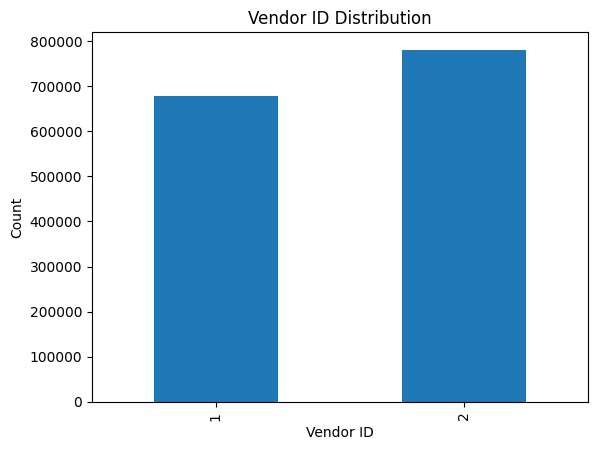

In [10]:
# Vendor ID Distribution
train_data["vendor_id"].value_counts().sort_values().plot(kind='bar')
plt.title("Vendor ID Distribution")
plt.xlabel("Vendor ID")
plt.ylabel("Count")
plt.show()

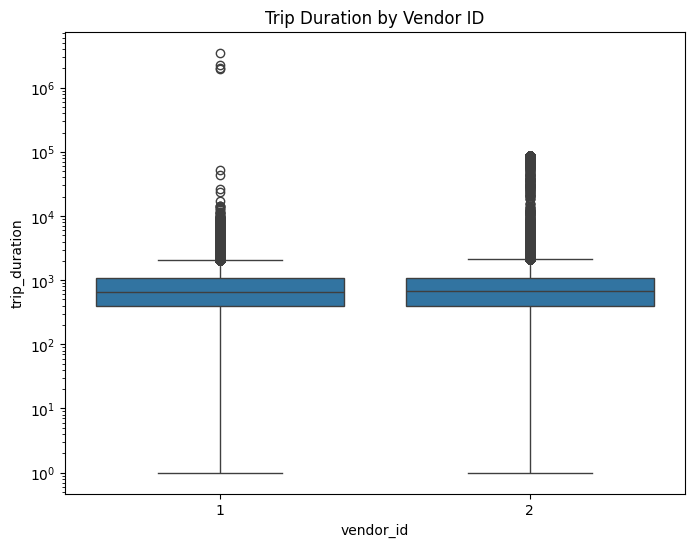

In [11]:
# Trip Duration Distribution by Vendor ID
plt.figure(figsize=(8, 6))

# Using log of trip_duration because it's usually heavily skewed
sns.boxplot(x='vendor_id', y='trip_duration', data=train_data)
plt.yscale('log') # Use log scale to handle outliers
plt.title('Trip Duration by Vendor ID')
plt.show()

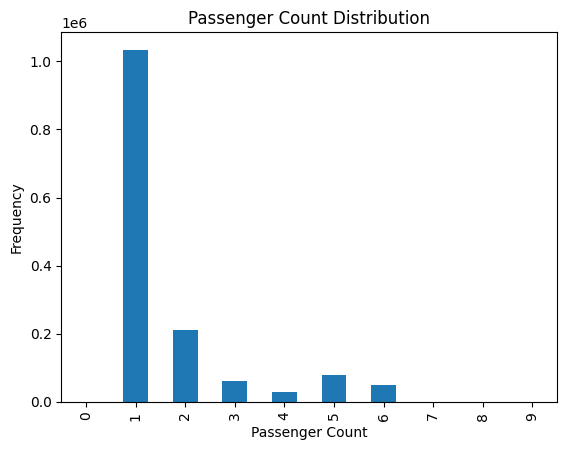

In [12]:
# Passenger Count Distribution
train_data["passenger_count"].value_counts().sort_index().plot(kind="bar")
plt.title("Passenger Count Distribution")
plt.xlabel("Passenger Count")
plt.ylabel("Frequency")
plt.show()

Zero passengers might indicate a canceled trip or a data entry error.

In [13]:
# Target variable exploration (outliers)
train_data["trip_duration"].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

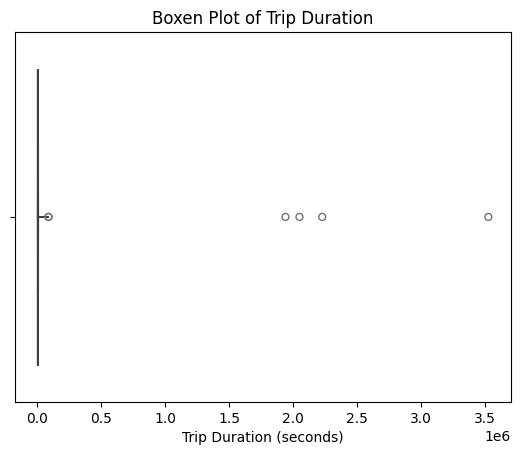

In [14]:
# Boxen plot of the target variable
sns.boxenplot(x=train_data["trip_duration"])
plt.title("Boxen Plot of Trip Duration")
plt.xlabel("Trip Duration (seconds)")
plt.show()

Dataset is extremely "bottom-heavy." With a median (50th percentile) of 662 but a maximum of 3,526,282.

The Floor: A taxi ride of 1 (unit) is likely a technical error or an immediate cancellation.

The Ceiling: A value of 3.5 million (40 days) is almost certainly a meter left running or a GPS glitch.

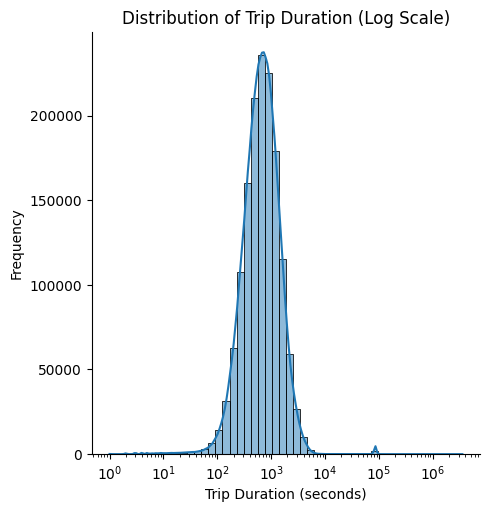

In [15]:
#Log-scale histogram of the target variable
sns.displot(train_data["trip_duration"], kind="hist", bins=50, log_scale=True, kde=True)
plt.title("Distribution of Trip Duration (Log Scale)")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

### Feature engineering

In [ ]:
"""
def preprocess_trip_data(df):
    # Remove trips with zero passengers
    df = df[df["passenger_count"] > 0]

    # Remove outliers based on trip duration (keep trips between 1 minute and 2 hours)
    df = df[(df["trip_duration"] > 60) &
            (df["trip_duration"] < 3600 * 2)]
    
    return df
"""

In [18]:
train_data_clean = preprocess_trip_data(train_data)
print("Train data after cleaning rows", train_data_clean.shape)

Train data after cleaning rows (1447597, 11)


In [18]:
def convert_to_datetime(df):
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    return df

def extract_datetime_features(df):
    df["pickup_hour"] = df["pickup_datetime"].dt.hour
    df["pickup_day"] = df["pickup_datetime"].dt.dayofweek
    df["pickup_month"] = df["pickup_datetime"].dt.month
    return df

def create_rush_hour_feature(df):
    df['rush_hour'] = (df['pickup_hour'].isin([8,9,10,16,17,18,19]).astype(int) & 
                       df['pickup_day'].isin([0,1,2,3,4]).astype(int))
    return df

In [19]:
train_data_clean = convert_to_datetime(train_data_clean)
train_data_clean = extract_datetime_features(train_data_clean)
train_data_clean = create_rush_hour_feature(train_data_clean)

train_data_clean.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,rush_hour
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,1
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,1
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,0


In [ ]:
# Manhattan distance function to calculate the distance between two points in a grid-based path (like navigating through city blocks)
def calculate_manhattan_distance(lat1, lon1, lat2, lon2):
    return np.abs(lat2 - lat1) + np.abs(lon2 - lon1)

In [ ]:
# Haversine distance function to calculate the great-circle distance between two points on the Earth
def calculate_haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lambda / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

In [ ]:
train_data_clean["manhattan_distance"] = calculate_manhattan_distance(train_data_clean["pickup_latitude"], train_data_clean["pickup_longitude"],
                                     train_data_clean["dropoff_latitude"], train_data_clean["dropoff_longitude"])

train_data_clean["haversine_distance"] = calculate_haversine_distance(train_data_clean["pickup_latitude"], train_data_clean["pickup_longitude"],
                                     train_data_clean["dropoff_latitude"], train_data_clean["dropoff_longitude"])

In [23]:
train_data_clean.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,rush_hour,manhattan_distance,haversine_distance
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,1,0.019859,0.026154
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,0,0.026478,0.031512
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,0,0.080158,0.111441
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,1,0.015480,0.025927
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,0,0.010818,0.020745


### Feature Sets

In [ ]:
# Prepare the data for modeling
BASE_FEATURES = ["vendor_id", "passenger_count", "pickup_hour", "pickup_day", "pickup_month"]

DISTANCE_FEATURES = BASE_FEATURES + ["manhattan_distance", "haversine_distance"]
ENGINEERED_FEATURES = DISTANCE_FEATURES + ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "rush_hour"]

### Models

In [ ]:
def get_random_forest_model():
    return RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

def get_xgboost_model():
    return XGBRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42)

def get_gbr_model():
    return GradientBoostingRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42)

def get_lgbm_model():
    return LGBMRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42)

def get_catboost_model():
    return CatBoostRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, verbose=0)

### Train validation split

In [ ]:
# Train models
def run_experiment(model, features, train_data):

    X = train_data[features]
    y = train_data["trip_duration"]

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    score = root_mean_squared_log_error(y_val, y_pred)
    
    #print(f"Model: {model.__class__.__name__}, Features: {features}, RMSLE: {score:.4f}")

    return score

### Track results

In [ ]:
best_result = []
best_score = float('inf')

results2 = []

experiments2 = [
    {"name": "RF_base", "model": get_random_forest_model(), "features": BASE_FEATURES},
    #{"name": "RF_haversine", "model": get_random_forest_model(), "features": HAVERSINE_DISTANCE},
    #{"name": "RF_manhattan", "model": get_random_forest_model(), "features": MANHATTAN_DISTANCE},
    #{"name": "XGB_base", "model": get_xgboost_model(), "features": BASE_FEATURES},
    #{"name": "XGB_haversine", "model": get_xgboost_model(), "features": HAVERSINE_DISTANCE},
    #{"name": "XGB_manhattan", "model": get_xgboost_model(), "features": MANHATTAN_DISTANCE},
    #{"name": "GBR_base", "model": get_gbr_model(), "features": BASE_FEATURES},
    #{"name": "GBR_haversine", "model": get_gbr_model(), "features": HAVERSINE_DISTANCE},
    {"name": "GBR_manhattan", "model": get_gbr_model(), "features": DISTANCE_FEATURES}
]

for exp in experiments2:
    score = run_experiment(exp["model"], exp["features"], train_data)

    results2.append({
        "name": exp["name"],
        "model": exp["model"],
        "features": exp["features"],
        "score": score
    })

    if score < best_score:
        best_score = score
        best_result = exp

    print(f"Experiment: {exp['name']}, Features: {exp['features']}, RMSLE: {score:.4f}")

In [ ]:
best_result["model"]

### Compare results

In [ ]:
results_df = pd.DataFrame(results2).sort_values("score")
results_df

In [ ]:
results_df["model"][:1]

In [ ]:
# Predict on test set
def predictor(model, train_data, test_data, features):
    
    X_test = test_data[features]

    model.fit(train_data[features], train_data["trip_duration"])

    Y_pred_test = model.predict(X_test)

    test_data["trip_duration"] = Y_pred_test

    return Y_pred_test

model = best_result["model"]
features = best_result["features"]

Y_pred_test = predictor(model, train_data, test_data, features)
print(Y_pred_test[:5])